## 11) Load Checkpoint And Build Evaluation State
This cell is self-contained: it loads the checkpoint, reconstructs the RNO model, loads Heat data,
and prepares `sol_test_chunks` for rollout testing.


### 11a) Imports and User Configuration


In [ ]:
# 11a) Imports and user-editable evaluation inputs
import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from neuralop.models import RNO

# Paths
checkpoint_path = "result_rno_state_only_32/rno_state_only_last.pt"
data_path = "/home/pk222/projects/PDEControl_DPC/datasets/heat_smooth_f_dataset.npz"

# Optional overrides; if None, values come from checkpoint config when available.
samples_to_load_override = None
train_frac_override = None

# Step 12 params
rollout_h = 5
sample_id = 0
start_chunk = 0

# Step 13 params
eval_steps = [1, 2, 4, 8, 12, 16, 20]
num_windows_per_traj = 10


### 11b) Load Checkpoint (Robust Weights-Only Fallback)


In [ ]:
# 11b) Load checkpoint robustly for PyTorch >=2.6
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

try:
    ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
    print("Loaded checkpoint with weights_only=True.")
except Exception as weights_only_error:
    ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    print(
        "Loaded checkpoint with weights_only=False fallback:",
        str(weights_only_error).splitlines()[0],
    )


### 11c) Parse Checkpoint and Build Model


In [ ]:
# 11c) Normalize checkpoint structure, build model, load weights, set seed/device
def parse_checkpoint(ckpt_obj):
    if isinstance(ckpt_obj, torch.nn.Module):
        return ckpt_obj.state_dict(), {}

    if not isinstance(ckpt_obj, dict):
        raise ValueError(f"Unsupported checkpoint object type: {type(ckpt_obj)}")

    if "model_state_dict" in ckpt_obj:
        state_dict = ckpt_obj["model_state_dict"]
        cfg_local = ckpt_obj.get("config", {})
        return state_dict, cfg_local

    return ckpt_obj, {}


state_dict, cfg = parse_checkpoint(ckpt)

if "_metadata" in state_dict and not torch.is_tensor(state_dict["_metadata"]):
    state_dict = {k: v for k, v in state_dict.items() if k != "_metadata"}

# Model hyperparameters
modes1 = cfg.get("modes1", 20)
modes2 = cfg.get("modes2", 20)
width = cfg.get("width", 28)
n_layers = cfg.get("n_layers", 3)
domain_padding = cfg.get("domain_padding", [0.1, 0])
in_channels = cfg.get("in_channels", 1)
out_channels = cfg.get("out_channels", 1)

# Data/chunking hyperparameters
chunk_len = cfg.get("chunk_len", 16)
n_intervals = cfg.get("n_intervals", 5)
sub = cfg.get("sub", 1)
train_frac_ckpt = cfg.get("train_frac", 0.8)

samples_to_load = (
    100 if samples_to_load_override is None else int(samples_to_load_override)
)
train_frac = float(
    train_frac_ckpt if train_frac_override is None else train_frac_override
)

seed = int(ckpt.get("seed", 32)) if isinstance(ckpt, dict) else 32
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required but not available.")
device = torch.device("cuda")

model = RNO(
    n_modes=(modes1, modes2),
    hidden_channels=width,
    in_channels=in_channels,
    out_channels=out_channels,
    n_layers=n_layers,
    domain_padding=domain_padding,
).to(device)
model.load_state_dict(state_dict, strict=True)
model.eval()

if model.in_channels != 1 or model.out_channels != 1:
    raise ValueError(
        f"This notebook expects state-only RNO with in=out=1. Got in={model.in_channels}, out={model.out_channels}."
    )

print("Checkpoint loaded:", checkpoint_path)
print(f"model.in_channels={model.in_channels}, model.out_channels={model.out_channels}")
print(
    f"seed={seed}, chunk_len={chunk_len}, n_intervals={n_intervals}, sub={sub}, train_frac={train_frac}"
)


### 11d) Load Heat Data and Build Test Chunks


In [ ]:
# 11d) Load data, preprocess, and build sol_test_chunks
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found: {data_path}")

dataset = np.load(data_path)
solutions = torch.from_numpy(
    dataset["solutions"][:samples_to_load]
).float()  # (ntraj, nt, nx)
x_cord = torch.from_numpy(dataset["x"]).reshape(-1, 1).float()
dt = float(dataset["dt"])

# Spatial subsample
solutions = solutions[:, :, ::sub]
x_cord = x_cord[::sub]

# Crop time to multiple of chunk_len
ntraj, nt_raw, nx = solutions.shape
nt_usable = nt_raw - (nt_raw % chunk_len)
solutions = solutions[:, :nt_usable, :]

# Same train/test trajectory split as training notebook
n_train_traj = int(train_frac * solutions.shape[0])
n_test_traj = solutions.shape[0] - n_train_traj
sol_test = solutions[n_train_traj:]  # (n_test_traj, nt, nx)


def chunk_time_axis(arr, size):
    return torch.stack(torch.split(arr, size, dim=1), dim=1)


sol_test_chunks = chunk_time_axis(sol_test, chunk_len).unsqueeze(
    -1
)  # (n_test_traj, n_chunks, chunk_len, nx, 1)

print(f"solutions shape: {tuple(solutions.shape)}")
print(f"sol_test_chunks shape: {tuple(sol_test_chunks.shape)}")
print(f"n_test_traj={n_test_traj}, dt={dt}")


## 12) Single-Trajectory Native Rollout Test
Runs `model.predict(x0_in, num_steps=rollout_h)` for one test trajectory and compares against ground truth.


x0_in shape: (1, 5, 1, 16, 100)
pred shape: (1, 5, 1, 16, 100)
true chunks shape: (5, 16, 100, 1)
Rollout MSE (h=5): 1.5305e+00
Rollout relative L2 (h=5): 8.6277e-01


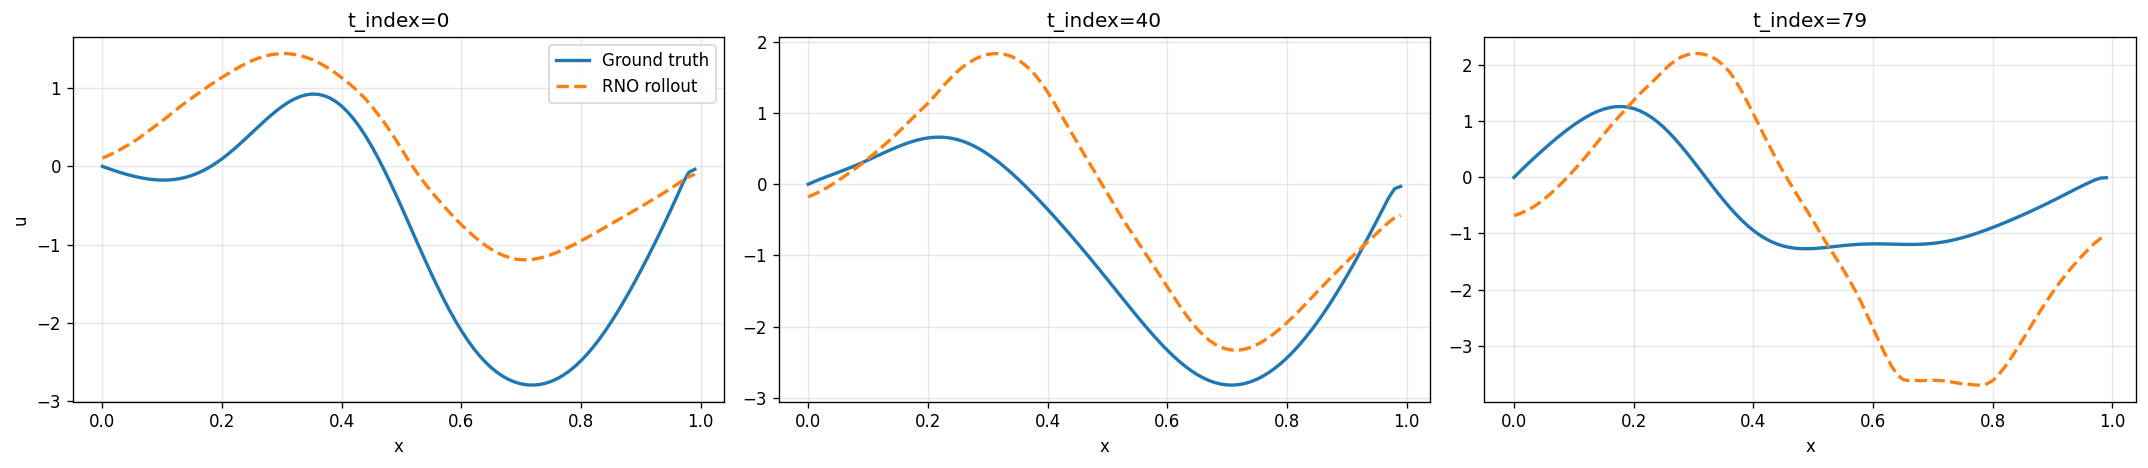

In [4]:
# 12) Single-trajectory rollout and visualization
assert rollout_h >= 1

traj = sol_test_chunks[sample_id]  # (n_chunks, chunk_len, nx, 1)
max_start = traj.shape[0] - n_intervals - rollout_h
if max_start < 0:
    raise ValueError(
        f"Not enough chunks for rollout_h={rollout_h}. Have n_chunks={traj.shape[0]}, n_intervals={n_intervals}."
    )

start = min(start_chunk, max_start)
x0 = traj[start : start + n_intervals].unsqueeze(
    0
)  # (1, n_intervals, chunk_len, nx, 1)
y_true_chunks = traj[
    start + n_intervals : start + n_intervals + rollout_h
]  # (rollout_h, chunk_len, nx, 1)

x0_in = (
    x0.to(device).permute(0, 1, 4, 2, 3).contiguous()
)  # (1, n_intervals, 1, chunk_len, nx)

model.eval()
with torch.no_grad():
    pred = model.predict(x0_in, num_steps=rollout_h)  # (1, rollout_h, 1, chunk_len, nx)

pred_chunks = (
    pred[0].permute(0, 2, 3, 1).detach().cpu()
)  # (rollout_h, chunk_len, nx, 1)
true_chunks = y_true_chunks.detach().cpu()  # (rollout_h, chunk_len, nx, 1)

pred_flat = pred_chunks.squeeze(-1).reshape(rollout_h * chunk_len, nx)
true_flat = true_chunks.squeeze(-1).reshape(rollout_h * chunk_len, nx)

mse_roll = torch.mean((pred_flat - true_flat) ** 2).item()
rel_l2_roll = (
    torch.linalg.norm(pred_flat - true_flat) / (torch.linalg.norm(true_flat) + 1e-12)
).item()

print(f"x0_in shape: {tuple(x0_in.shape)}")
print(f"pred shape: {tuple(pred.shape)}")
print(f"true chunks shape: {tuple(true_chunks.shape)}")
print(f"Rollout MSE (h={rollout_h}): {mse_roll:.4e}")
print(f"Rollout relative L2 (h={rollout_h}): {rel_l2_roll:.4e}")

# Quick line comparison at a few rollout times
x_axis = x_cord.squeeze().cpu().numpy()
ids = [0, max(0, (rollout_h * chunk_len) // 2), rollout_h * chunk_len - 1]
fig, axes = plt.subplots(1, 3, figsize=(18, 4), dpi=120)
for ax, tid in zip(axes, ids):
    ax.plot(
        x_axis,
        true_flat[tid].numpy(),
        label="Ground truth",
        color="#1f77b4",
        linewidth=2,
    )
    ax.plot(
        x_axis,
        pred_flat[tid].numpy(),
        label="RNO rollout",
        color="#ff7f0e",
        linestyle="--",
        linewidth=2,
    )
    ax.set_title(f"t_index={tid}")
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("u")
axes[0].legend(loc="best")
plt.tight_layout()
plt.show()


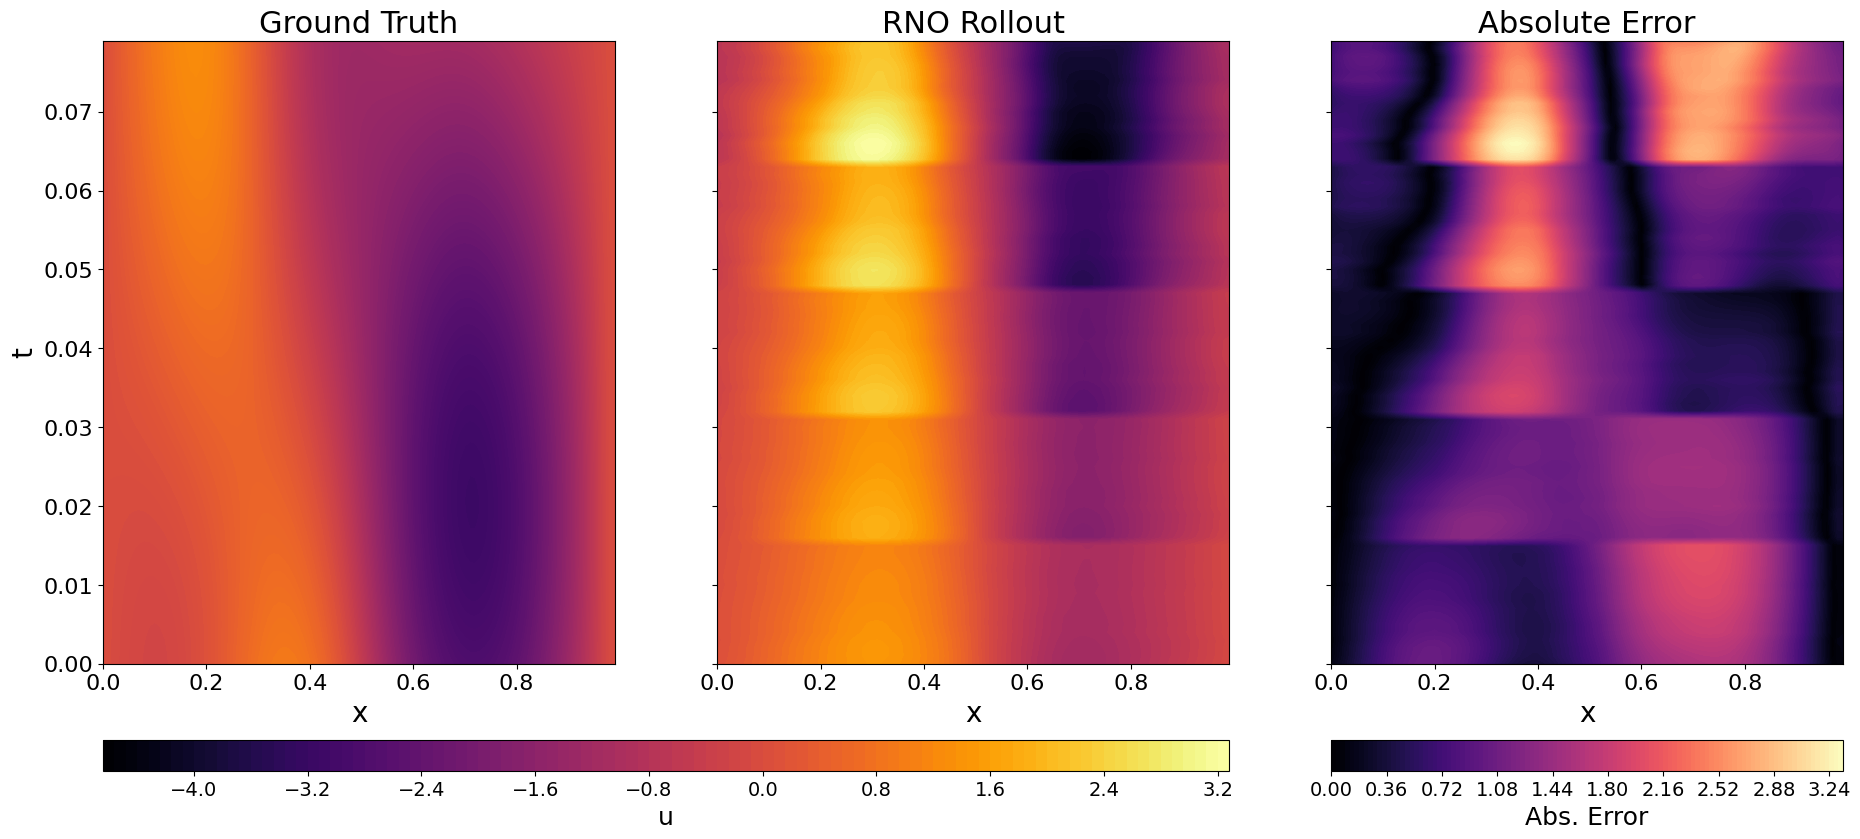

In [ ]:
# 12b) Contour-style comparison, matching prior notebook style family
# Uses tensors prepared in the previous section-12 rollout cell: true_flat, pred_flat, x_axis, rollout_h, chunk_len, dt

true_np = true_flat.detach().cpu().numpy()
pred_np = pred_flat.detach().cpu().numpy()
err_np = np.abs(true_np - pred_np)
time_axis = np.linspace(0.0, dt * (rollout_h * chunk_len - 1), rollout_h * chunk_len)

# Save directory for section-12 figures
result_dir = os.path.join("heat", f"result_rno_state_only_eval_{seed}")
os.makedirs(result_dir, exist_ok=True)

# If the line plot path wasn't saved in the previous cell, define a placeholder for printing consistency
if "line_plot_path" not in globals():
    line_plot_path = os.path.join(result_dir, f"rollout_lines_h{rollout_h}.png")

# Contour-style comparison, matching prior notebook style family
vmin = float(min(true_np.min(), pred_np.min()))
vmax = float(max(true_np.max(), pred_np.max()))

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(
    3,
    3,
    height_ratios=[20, 0.3, 1.0],
    width_ratios=[1, 1, 1],
    hspace=0.15,
    wspace=0.2,
    bottom=0.15,
    top=0.88,
    left=0.08,
    right=0.95,
)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
ax2 = fig.add_subplot(gs[0, 2], sharey=ax0)

im0 = ax0.contourf(
    x_axis, time_axis, true_np, levels=120, cmap="inferno", vmin=vmin, vmax=vmax
)
ax0.set_title("Ground Truth", fontsize=22)
ax0.set_xlabel("x", fontsize=20)
ax0.set_ylabel("t", fontsize=20)
ax0.tick_params(labelsize=16)

im1 = ax1.contourf(
    x_axis, time_axis, pred_np, levels=120, cmap="inferno", vmin=vmin, vmax=vmax
)
ax1.set_title("RNO Rollout", fontsize=22)
ax1.set_xlabel("x", fontsize=20)
ax1.tick_params(labelsize=16, labelleft=False)

im2 = ax2.contourf(x_axis, time_axis, err_np, levels=120, cmap="magma")
ax2.set_title("Absolute Error", fontsize=22)
ax2.set_xlabel("x", fontsize=20)
ax2.tick_params(labelsize=16, labelleft=False)

cbar_ax1 = fig.add_subplot(gs[2, 0:2])
cbar1 = fig.colorbar(im1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("u", fontsize=18)
cbar1.ax.tick_params(labelsize=14)

cbar_ax2 = fig.add_subplot(gs[2, 2])
cbar2 = fig.colorbar(im2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Abs. Error", fontsize=18)
cbar2.ax.tick_params(labelsize=14)

plt.show()

## 13) Multi-Horizon Endpoint Testing (KS-style)
For each horizon `h`, computes endpoint-only metrics over sampled test windows:
- endpoint MSE
- endpoint relative L2


In [5]:
# 13) Multi-horizon endpoint-only evaluation table
rng = np.random.default_rng(seed)
results = {}

model.eval()
with torch.no_grad():
    for h in eval_steps:
        mse_vals = []
        rel_l2_vals = []
        n_eval = 0

        for traj_idx in range(sol_test_chunks.shape[0]):
            traj = sol_test_chunks[traj_idx]  # (n_chunks, chunk_len, nx, 1)
            max_start = traj.shape[0] - n_intervals - h
            if max_start < 0:
                continue

            all_starts = np.arange(max_start + 1)
            if len(all_starts) <= num_windows_per_traj:
                starts = all_starts
            else:
                starts = np.sort(
                    rng.choice(all_starts, size=num_windows_per_traj, replace=False)
                )

            for start in starts:
                # context + endpoint target at horizon h
                x0 = traj[start : start + n_intervals].unsqueeze(
                    0
                )  # (1, n_intervals, chunk_len, nx, 1)
                y_h = (
                    traj[start + n_intervals + (h - 1)].unsqueeze(0).to(device)
                )  # (1, chunk_len, nx, 1)

                x0_in = (
                    x0.to(device).permute(0, 1, 4, 2, 3).contiguous()
                )  # (1, n_intervals, 1, chunk_len, nx)
                pred = model.predict(x0_in, num_steps=h)  # (1, h, 1, chunk_len, nx)

                pred_h = pred[:, -1]  # (1, 1, chunk_len, nx)
                pred_h = pred_h.permute(0, 2, 3, 1)  # (1, chunk_len, nx, 1)

                mse = torch.mean((pred_h - y_h) ** 2).item()
                diff_flat = (pred_h - y_h).reshape(1, -1)
                y_flat = y_h.reshape(1, -1)
                rel_l2 = (
                    torch.linalg.norm(diff_flat, dim=1)
                    / (torch.linalg.norm(y_flat, dim=1) + 1e-12)
                ).item()

                mse_vals.append(mse)
                rel_l2_vals.append(rel_l2)
                n_eval += 1

        if n_eval > 0:
            results[h] = {
                "mse_mean": float(np.mean(mse_vals)),
                "rel_l2_mean": float(np.mean(rel_l2_vals)),
                "N": int(n_eval),
            }
        else:
            results[h] = {"mse_mean": float("nan"), "rel_l2_mean": float("nan"), "N": 0}

print("Steps | Endpoint MSE | Endpoint RelL2 | N")
for h in eval_steps:
    r = results[h]
    print(f"{h:>5} | {r['mse_mean']:.4e} | {r['rel_l2_mean']:.4e} | {r['N']}")


Steps | Endpoint MSE | Endpoint RelL2 | N
    1 | 6.1862e-01 | 8.6739e-01 | 200
    2 | 1.1367e+00 | 1.2622e+00 | 200
    4 | 4.0634e+00 | 2.3601e+00 | 200
    8 | 4.3390e+01 | 7.1405e+00 | 200
   12 | 5.0601e+02 | 2.2725e+01 | 180
   16 | 1.6225e+04 | 1.0984e+02 | 100
   20 | 6.2027e+05 | 6.5520e+02 | 20
